In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/Dataset.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [14]:
"""
Step 1: Organize content by release year.

I grouped the Netflix dataset based on the release_year column to organize
content according to the year it was released. This step helps transform
the raw data into a structured format where each year can be analyzed
individually.

Grouping the data by year allows us to study how Netflix's content library
has changed over time and prepares the data for calculating yearly release
counts and identifying trends.
"""

"\nStep 1: Organize content by release year.\n\nI grouped the dataset by the 'release_year' column to count the number of\nmovies and TV shows released each year. Then, I converted the result into a\nDataFrame to make it easier to visualize and analyze in the following steps.\n"

In [25]:
"""
Step 2: Calculate yearly content releases.

After grouping the data by release year, I calculated the number of titles
released in each year using the size() function. This provides the total
content releases per year.

The yearly counts allow us to measure Netflix's content production activity
and compare the number of releases between different years.
"""

"\nStep 2: Calculate yearly content releases.\n\nAfter grouping the data by release year, I calculated the number of titles\nreleased in each year using the size() function. This provides the total\ncontent releases per year.\n\nThe yearly counts allow us to measure Netflix's content production activity\nand compare the number of releases between different years.\n"

In [13]:
yearly_content=df.groupby("release_year").size().reset_index(name="content_count")
print(yearly_content)


    release_year  content_count
0           1925              1
1           1942              2
2           1943              3
3           1944              3
4           1945              4
..           ...            ...
69          2017           1030
70          2018           1146
71          2019           1030
72          2020            953
73          2021            592

[74 rows x 2 columns]


In [19]:
"""
Step 3: Identify growth and decline trends.

I analyzed the yearly release counts by calculating the difference between
each year and the previous year. Positive values indicate growth in content
releases, while negative values indicate a decline.

This analysis helps identify periods of expansion, slowdown, and major
changes in Netflix's content production over time.
"""

'\nStep 3: Identify growth and decline trends.\n\nI calculated the yearly changes in content releases by comparing each year\nwith the previous year. Positive values represent growth in content production,\nwhile negative values represent a decline. The analysis shows that Netflix\ncontent releases increased significantly until 2018, then decreased in the\nfollowing years.\nthe change column indecates the growth and decline in content production\n'

In [20]:
yearly_content["change"] = yearly_content["content_count"].diff()
print(yearly_content)


    release_year  content_count  change
0           1925              1     NaN
1           1942              2     1.0
2           1943              3     1.0
3           1944              3     0.0
4           1945              4     1.0
..           ...            ...     ...
69          2017           1030   129.0
70          2018           1146   116.0
71          2019           1030  -116.0
72          2020            953   -77.0
73          2021            592  -361.0

[74 rows x 3 columns]


In [28]:
# I would add is a growth percentage instead of only change, because it gives a clearer business view:
yearly_content["growth_percentage"] = (
    yearly_content["content_count"].pct_change() * 100
)
print(yearly_content)

    release_year  content_count  change  growth_percentage
0           1925              1     NaN                NaN
1           1942              2     1.0         100.000000
2           1943              3     1.0          50.000000
3           1944              3     0.0           0.000000
4           1945              4     1.0          33.333333
..           ...            ...     ...                ...
69          2017           1030   129.0          14.317425
70          2018           1146   116.0          11.262136
71          2019           1030  -116.0         -10.122164
72          2020            953   -77.0          -7.475728
73          2021            592  -361.0         -37.880378

[74 rows x 4 columns]


In [ ]:
"""
Step 4: Create trend visualizations.

I used a line chart to visualize Netflix content releases over time because
line charts are the most suitable visualization for time-series data.

The line chart clearly represents continuous changes across years and makes
it easier to identify overall trends, growth periods, decline periods, peak
years, and changes in Netflix's content strategy.
"""

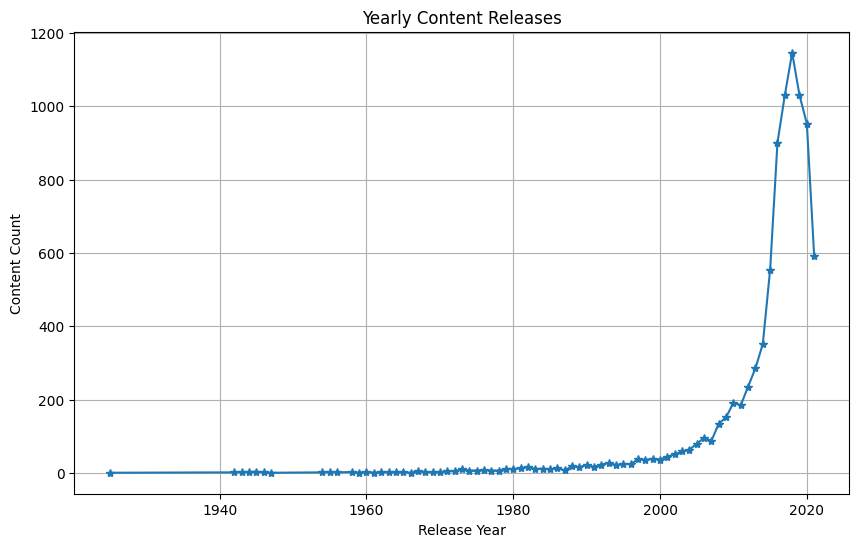

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.plot(yearly_content["release_year"], yearly_content["content_count"], marker="*")
plt.title("Yearly Content Releases")
plt.xlabel("Release Year")
plt.ylabel("Content Count")
plt.grid(True)
plt.show()

In [ ]:
"""
Step 5: Interpret business patterns.

The trend analysis shows that Netflix content releases increased significantly
until 2018, which represents the peak year with the highest number of
released titles in the dataset.

After 2018, the number of releases started to decline, with a noticeable
decrease in 2021. This pattern may indicate changes in Netflix's content
strategy, production capacity, or external factors affecting content
production.

These insights help understand how Netflix's content library evolved over
time.
"""